# How Does a Machine Learning Model Learn from Data?
Author: Wardatul Keskin
### A practical example using MovieLens

## 1. Define the Problem

How can a machine learning model use previous movie ratings to
predict how a user might rate a movie they have not rated yet?

In this notebook, each observed user–movie rating is a learning example:

- **Inputs:** the user identifier and movie identifier.
- **Target:** the rating the user gave that movie.
- **Task:** predict a numerical rating.

We will train a model on a portion of the observed ratings and evaluate
its predictions on held-out ratings.

To determine whether learning helps, we will compare the model with
a simple baseline that always predicts the average training rating.

### What does “learning” mean here?

The model adjusts its internal parameters using prediction errors
from the training data. We will track those errors during training
and check whether predictions also improve on validation data.

Success means predicting held-out ratings more accurately than
the baseline. A lower training error alone is not enough.

## 2. Introduce the Dataset

This notebook uses MovieLens ml-latest, generated on July 20, 2023,
provided by the GroupLens Research Group.

According to the accompanying README, this release contains:
- 33,832,162 ratings.
- 330,975 users.
- 86,537 movies.
- Ratings from January 1995 to July 2023.

Each ratings.csv row represents one user's rating of one movie.
Ratings range from 0.5 to 5.0 stars in half-star increments.

We will initially use:
- ratings.csv: observed user–movie ratings.
- movies.csv: movie titles and genres.

The remaining files provide external identifiers, user-applied tags,
and movie–tag relevance scores.

This is a development dataset that can change over time.
We record the release date to identify the version used here.

Reference:
Harper, F. M., & Konstan, J. A. (2015).
The MovieLens datasets: History and context.
https://doi.org/10.1145/2827872

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Reproducibility for NumPy-based operations.
SEED = 42
rng = np.random.default_rng(SEED)

# Reusable colours for charts throughout the notebook.
COLORS = {
    "primary": "#245A81",
    "accent": "#16827C",
    "baseline": "#707780",
    "highlight": "#C47624",
}

sns.set_theme(
    context="notebook",
    style="whitegrid",
    palette="colorblind",
    font="DejaVu Sans",
    rc={
        "figure.figsize": (9, 5),
        "figure.dpi": 120,
        "figure.constrained_layout.use": True,
        "axes.titlesize": 15,
        "axes.titleweight": "bold",
        "axes.titlepad": 14,
        "axes.labelsize": 12,
        "axes.labelpad": 8,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.edgecolor": "#C3CAD2",
        "grid.color": "#E5E9EF",
        "grid.linewidth": 0.6,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "lines.linewidth": 2,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
        "savefig.facecolor": "white",
    },
)

pd.set_option("display.max_columns", 20)
pd.set_option("display.precision", 3)

print("Notebook setup complete.")

Notebook setup complete.


## 3. Load the data

In [2]:
# Load the data
DATA_DIR = Path(r"D:\WKESKIN\MyProject\Blogger\postings\MovieLense\ml-latest")

if not DATA_DIR.is_dir():
    raise FileNotFoundError(
        f"Dataset folder not found: {DATA_DIR}\n"
        "Update DATA_DIR to your extracted MovieLens folder."
    )

csv_files = sorted(DATA_DIR.glob("*.csv"))

file_inventory = pd.DataFrame([
    {
        "File": path.name,
        "Size (MB)": round(path.stat().st_size / 1_000_000, 2),
    }
    for path in csv_files
])

display(file_inventory)

,File,Size (MB)
0,genome-scores.csv,521.51
1,genome-tags.csv,0.02
2,links.csv,1.93
3,movies.csv,4.19
4,ratings.csv,933.90
5,tags.csv,85.36


In [3]:
# Inspect headers and preview each file
previews = {}

for path in csv_files:
    preview = pd.read_csv(path, nrows=5, encoding="utf-8")
    previews[path.stem] = preview

    print(f"\n{path.name}")
    print(f"Columns: {preview.columns.tolist()}")
    display(preview)


genome-scores.csv
Columns: ['movieId', 'tagId', 'relevance']


,movieId,tagId,relevance
0,1,1,0.032
1,1,2,0.022
2,1,3,0.070
3,1,4,0.059
4,1,5,0.123



genome-tags.csv
Columns: ['tagId', 'tag']


,tagId,tag
0,1,007
1,2,007 (series)
2,3,18th century
3,4,1920s
4,5,1930s



links.csv
Columns: ['movieId', 'imdbId', 'tmdbId']


...

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy



ratings.csv
Columns: ['userId', 'movieId', 'rating', 'timestamp']


,userId,movieId,rating,timestamp
0,1,1,4.0,1225734739
1,1,110,4.0,1225865086
2,1,158,4.0,1225733503
3,1,260,4.5,1225735204
4,1,356,5.0,1225735119



tags.csv
Columns: ['userId', 'movieId', 'tag', 'timestamp']


,userId,movieId,tag,timestamp
0,10,260,good vs evil,1430666558
1,10,260,Harrison Ford,1430666505
2,10,260,sci-fi,1430666538
3,14,1221,Al Pacino,1311600756
4,14,1221,mafia,1311600746


In [4]:
# Load the movie metadata
movies = pd.read_csv(
    DATA_DIR / "movies.csv",
    encoding="utf-8",
)

print(f"Movie metadata rows: {len(movies):,}")
display(movies.head())
movies.info()

Movie metadata rows: 86,537


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86537 entries, 0 to 86536
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  86537 non-null  int64 
 1   title    86537 non-null  object
 2   genres   86537 non-null  object
dtypes: int64(1), object(2)
memory usage: 2.0+ MB


In [5]:
# Load the ratings
rating_dtypes = {
    "userId": "int32",
    "movieId": "int32",
    "rating": "float32",
    "timestamp": "int64",
}

ratings = pd.read_csv(
    DATA_DIR / "ratings.csv",
    usecols=list(rating_dtypes),
    dtype=rating_dtypes,
    encoding="utf-8",
)
print(f"Loaded ratings: {len(ratings):,}")
print(
    "DataFrame memory: "
    f"{ratings.memory_usage(deep=True).sum() / 1_000_000:,.1f} MB"
)

Loaded ratings: 33,832,162
DataFrame memory: 676.6 MB


In [6]:
# Preview the data
print("First five ratings")
display(ratings.head())

print("\nFive randomly selected ratings")
display(ratings.sample(n=5, random_state=SEED))

First five ratings


,userId,movieId,rating,timestamp
0,1,1,4.0,1225734739
1,1,110,4.0,1225865086
2,1,158,4.0,1225733503
3,1,260,4.5,1225735204
4,1,356,5.0,1225735119



Five randomly selected ratings


,userId,movieId,rating,timestamp
2389351,23474,8636,2.0,1623093417
33507715,327932,480,2.0,975014893
3360596,32973,5481,0.5,1057540085
17752905,174379,7325,3.5,1081659178
20252033,197873,2467,4.5,1206690610


In [7]:
# Inspect columns and data types
ratings.info()

print("\nNumerical summary")
display(ratings.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33832162 entries, 0 to 33832161
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   userId     int32  
 1   movieId    int32  
 2   rating     float32
 3   timestamp  int64  
dtypes: float32(1), int32(2), int64(1)
memory usage: 645.3 MB

Numerical summary


,userId,movieId,rating,timestamp
count,3.383e+07,3.383e+07,3.383e+07,3.383e+07
mean,1.654e+05,2.831e+04,3.543e+00,1.269e+09
std,9.534e+04,4.993e+04,1.085e+00,2.541e+08
min,1.000e+00,1.000e+00,5.000e-01,7.897e+08
25%,8.295e+04,1.219e+03,3.000e+00,1.047e+09
50%,1.661e+05,3.263e+03,4.000e+00,1.265e+09
75%,2.474e+05,4.049e+04,4.000e+00,1.497e+09
max,3.310e+05,2.890e+05,5.000e+00,1.690e+09


In [8]:
# Summarize coverage
rating_dates = pd.to_datetime(
    [
        ratings["timestamp"].min(),
        ratings["timestamp"].max(),
    ],
    unit="s",
    utc=True,
)

dataset_summary = pd.DataFrame({
    "Measure": [
        "Observed ratings",
        "Distinct users",
        "Movies with ratings",
        "Movies in metadata",
        "Lowest observed rating",
        "Highest observed rating",
        "Earliest rating date (UTC)",
        "Latest rating date (UTC)",
    ],
    "Value": [
        f"{len(ratings):,}",
        f"{ratings['userId'].nunique():,}",
        f"{ratings['movieId'].nunique():,}",
        f"{len(movies):,}",
        ratings["rating"].min(),
        ratings["rating"].max(),
        rating_dates[0].strftime("%Y-%m-%d"),
        rating_dates[1].strftime("%Y-%m-%d"),
    ],
})

display(dataset_summary)

,Measure,Value
0,Observed ratings,"33,832,162"
1,Distinct users,"330,975"
2,Movies with ratings,"83,239"
3,Movies in metadata,"86,537"
4,Lowest observed rating,0.5
5,Highest observed rating,5.0
6,Earliest rating date (UTC),1995-01-09
7,Latest rating date (UTC),2023-07-20


In [9]:
# Preview ratings alongside movie titles
rating_examples = (
    ratings.sample(n=10, random_state=SEED)
    .merge(
        movies[["movieId", "title"]],
        on="movieId",
        how="left",
        validate="many_to_one",
    )
)

display(
    rating_examples[
        ["userId", "movieId", "title", "rating", "timestamp"]
    ].reset_index(drop=True)
)

,userId,movieId,title,rating,timestamp
0,23474,8636,Spider-Man 2 (2004),2.0,1623093417
1,327932,480,Jurassic Park (1993),2.0,975014893
2,32973,5481,Austin Powers in Goldmember (2002),0.5,1057540085
3,174379,7325,Starsky & Hutch (2004),3.5,1081659178
4,197873,2467,"Name of the Rose, The (Name der Rose, Der) (1986)",4.5,1206690610
5,32973,7153,"Lord of the Rings: The Return of the King, The...",5.0,1082262726
6,56305,588,Aladdin (1992),4.0,1419044641
7,303643,8665,"Bourne Supremacy, The (2004)",4.5,1552078915
8,268259,2772,Detroit Rock City (1999),5.0,974758533
9,146353,5618,Spirited Away (Sen to Chihiro no kamikakushi) ...,5.0,1437598925


## 4. Check Data Quality
Before training, we check whether:
- Required fields contain missing values.
- User–movie pairs appear more than once.
- Movie metadata contains duplicate movie IDs.
- Ratings follow the expected 0.5–5.0 scale and half-star increments.
- Every rated movie has matching metadata.

We will investigate any issues before deciding how to handle them.

In [10]:
# Check missing values
missing_summary = pd.concat(
    [
        ratings.isna().sum().rename("ratings"),
        movies.isna().sum().rename("movies"),
    ],
    axis=1,
).T

# A dash means the column does not belong to that table.
display(missing_summary.fillna("—"))

,userId,movieId,rating,timestamp,title,genres
ratings,0.0,0.0,0.0,0.0,—,—
movies,—,0.0,—,—,0.0,0.0


In [11]:
# Check duplicate user–movie pairs
duplicate_pairs = ratings.duplicated(
    subset=["userId", "movieId"],
    keep="first",
)

print(
    "Additional rows with an existing user–movie pair: "
    f"{duplicate_pairs.sum():,}"
)

if duplicate_pairs.any():
    display(ratings.loc[duplicate_pairs].head(10))

del duplicate_pairs

Additional rows with an existing user–movie pair: 0


In [12]:
# Check movie identifiers
duplicate_movie_ids = movies["movieId"].duplicated(keep=False)

print(
    "Metadata rows belonging to repeated movie IDs: "
    f"{duplicate_movie_ids.sum():,}"
)

if duplicate_movie_ids.any():
    display(
        movies.loc[duplicate_movie_ids]
        .sort_values("movieId")
        .head(10)
    )

Metadata rows belonging to repeated movie IDs: 0


In [13]:
# Validate the rating scale
observed_ratings = np.sort(ratings["rating"].dropna().unique())
allowed_ratings = np.arange(0.5, 5.1, 0.5)
invalid_ratings = observed_ratings[~np.isin(observed_ratings, allowed_ratings)]
formatted_ratings ="["+"; ".join(f"{value:.1f}" for value in observed_ratings)+"]"

print("Observed rating values:", formatted_ratings)
print("Values outside the expected scale:", invalid_ratings)

rating_counts = (
    ratings["rating"]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("Rating")
    .reset_index(name="Number of ratings")
)

display(rating_counts)

Observed rating values: [0.5; 1.0; 1.5; 2.0; 2.5; 3.0; 3.5; 4.0; 4.5; 5.0]
Values outside the expected scale: []


,Rating,Number of ratings
0,0.5,566306
1,1.0,1013645
2,1.5,562409
3,2.0,2146492
4,2.5,1760733
5,3.0,6400664
6,3.5,4465001
7,4.0,8835955
8,4.5,3123055
9,5.0,4957902


## 5. Explore Rating Patterns

<b> 5.1 Distribution of Movie Ratings</b>

We count how often each star rating appears in the dataset.

This helps us understand whether ratings are evenly distributed
or concentrated around particular values.

The chart describes observed ratings, rather than all movie viewers'
preferences: users choose which movies to watch and rate.

In [14]:
rating_distribution = (
    ratings["rating"]
    .value_counts()
    .reindex(np.arange(0.5, 5.1, 0.5), fill_value=0)
    .rename_axis("rating")
    .reset_index(name="count")
)

rating_distribution["percentage"] = (
    rating_distribution["count"]
    / rating_distribution["count"].sum()
    * 100
)

display(
    rating_distribution.style.format({
        "rating": "{:.1f}",
        "count": "{:,.0f}",
        "percentage": "{:.2f}%",
    })
)

,rating,count,percentage
0,0.5,"566,306",1.67%
1,1.0,"1,013,645",3.00%
2,1.5,"562,409",1.66%
3,2.0,"2,146,492",6.34%
4,2.5,"1,760,733",5.20%
5,3.0,"6,400,664",18.92%
6,3.5,"4,465,001",13.20%
7,4.0,"8,835,955",26.12%
8,4.5,"3,123,055",9.23%
9,5.0,"4,957,902",14.65%


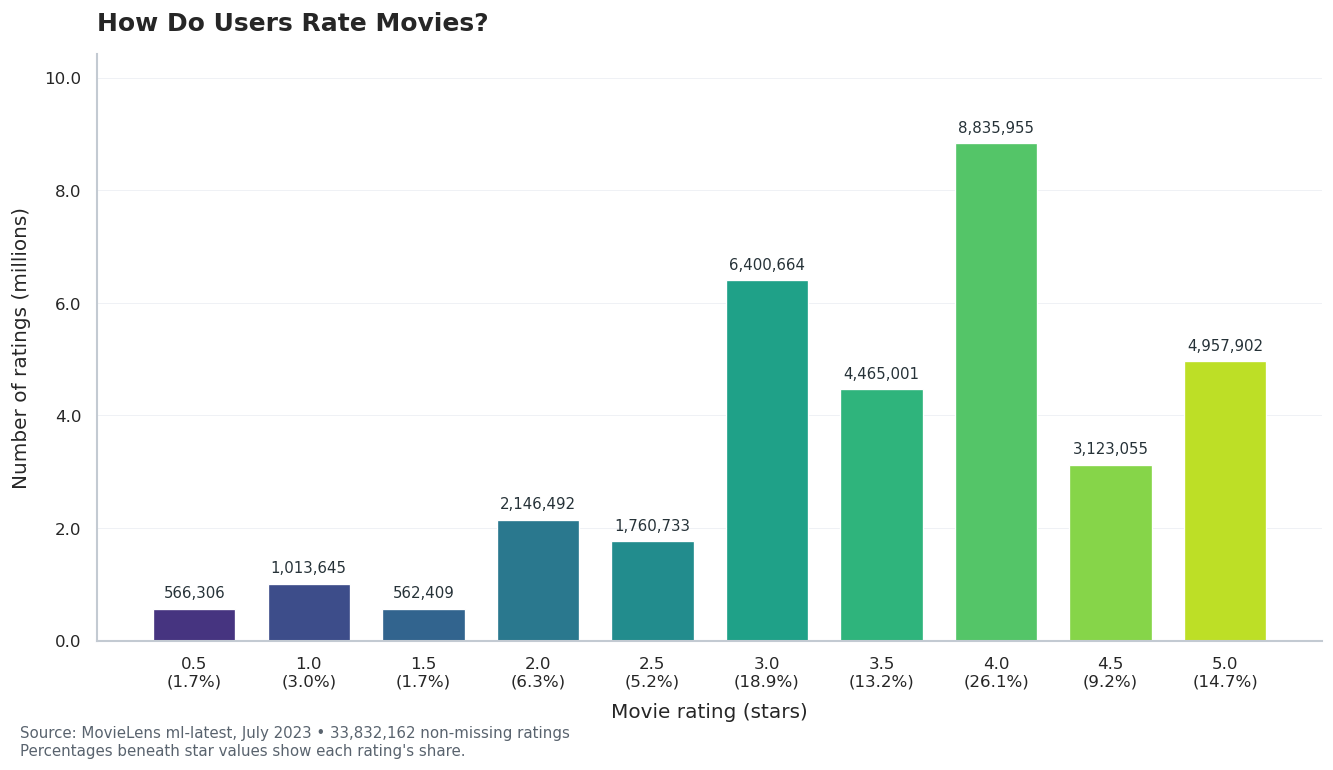

In [15]:
# Create the visualization
from matplotlib.ticker import FuncFormatter

fig, ax = plt.subplots(figsize=(11, 6))

positions = np.arange(len(rating_distribution))
bar_colors = plt.colormaps["viridis"](
    np.linspace(0.15, 0.90, len(rating_distribution))
)

bars = ax.bar(
    positions,
    rating_distribution["count"],
    color=bar_colors,
    width=0.72,
    edgecolor="white",
    linewidth=0.8,
)

ax.set_title("How Do Users Rate Movies?", loc="left")
ax.set_xlabel("Movie rating (stars)")
ax.set_ylabel("Number of ratings (millions)")

ax.set_xticks(positions)
ax.set_xticklabels(
    [
        f"{row.rating:.1f}\n({row.percentage:.1f}%)"
        for row in rating_distribution.itertuples(index=False)
    ]
)

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda value, _: f"{value / 1_000_000:.1f}")
)

ax.bar_label(
    bars,
    labels=[
        f"{count:,.0f}"
        for count in rating_distribution["count"]
    ],
    padding=5,
    fontsize=9,
    color="#263238",
)

ax.set_ylim(0, rating_distribution["count"].max() * 1.18)
ax.set_axisbelow(True)
ax.grid(axis="x", visible=False)
ax.grid(axis="y", alpha=0.6)

sns.despine(ax=ax)

fig.text(
    0.01,
    -0.04,
    f"Source: MovieLens ml-latest, July 2023 • "
    f"{rating_distribution['count'].sum():,} non-missing ratings\n"
    "Percentages beneath star values show each rating's share.",
    fontsize=9,
    color="#59636E",
)

plt.show()

In [16]:
# Generate numerical observations
most_common = rating_distribution.loc[
    rating_distribution["count"].idxmax()
]

share_four_plus = (
    rating_distribution.loc[
        rating_distribution["rating"] >= 4.0,
        "percentage",
    ].sum()
)

print(f"Mean rating: {ratings['rating'].mean():.2f} stars")
print(f"Median rating: {ratings['rating'].median():.1f} stars")
print(
    f"Most frequent rating: {most_common['rating']:.1f} stars "
    f"({most_common['percentage']:.2f}% of ratings)"
)
print(f"Ratings of 4.0 stars or higher: {share_four_plus:.2f}%")

Mean rating: 3.54 stars
Median rating: 4.0 stars
Most frequent rating: 4.0 stars (26.12% of ratings)
Ratings of 4.0 stars or higher: 50.00%


<b> 5.2 How Many Movies Has Each User Rated? </b></br>
Users contribute different numbers of ratings.
We examine the distribution of ratings per user to understand how
much evidence is available for learning individual preferences.
The histogram uses a logarithmic horizontal axis to show both
users with few ratings and users with many ratings.

In [17]:
# Count ratings per user
user_rating_counts = (
    ratings.groupby("userId", sort=False)
    .size()
    .rename("rating_count")
)

user_summary = (
    user_rating_counts.describe(
        percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
    .rename_axis("Statistic")
    .reset_index(name="Ratings per user")
)

display(
    user_summary.style.format({"Ratings per user": "{:,.2f}"})
)

,Statistic,Ratings per user
0,count,"330,975.00"
1,mean,102.22
2,std,232.15
3,min,1.00
4,25%,15.00
5,50%,31.00
6,75%,98.00
7,90%,250.00
8,95%,421.00
9,99%,"1,046.00"


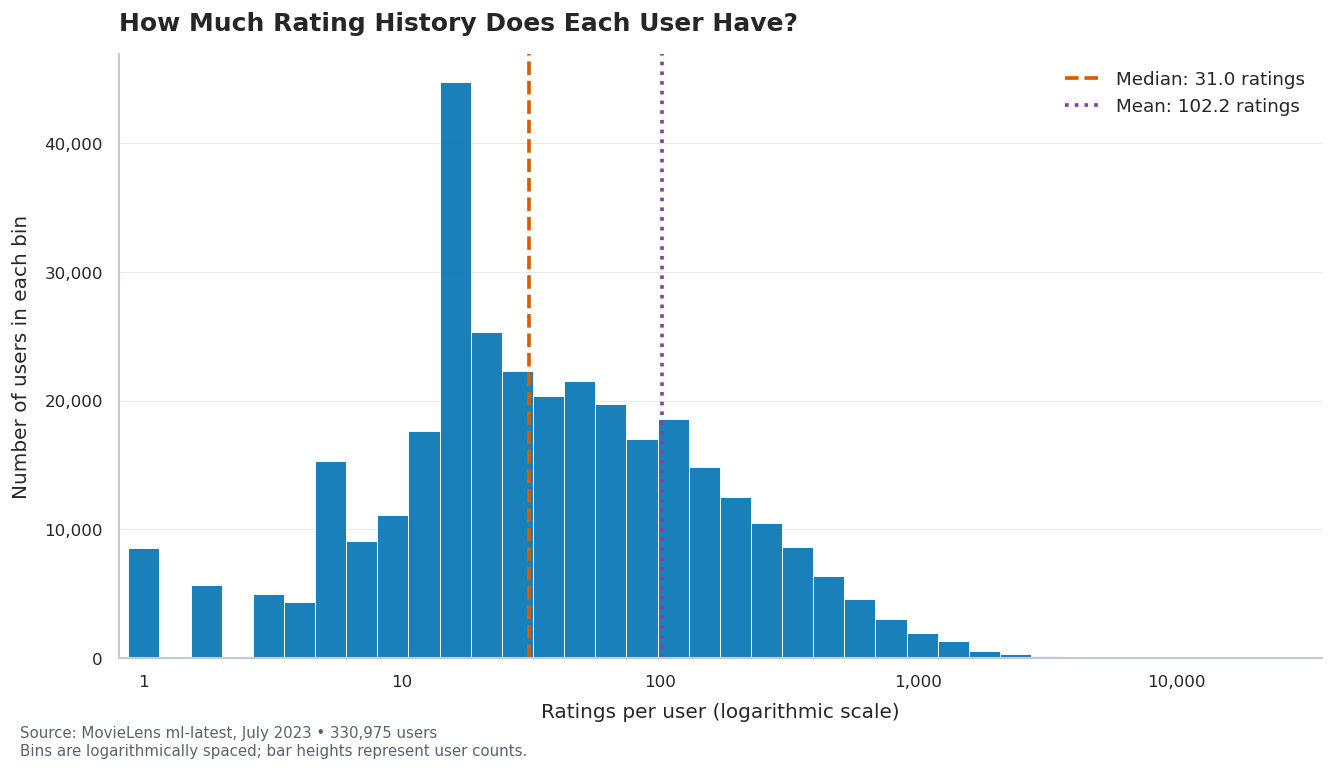

In [18]:
# Visualize the distribution
from matplotlib.ticker import FuncFormatter
counts = user_rating_counts.to_numpy()

# Geometric bin edges cover every user's positive rating count.
bin_edges = np.geomspace(
    0.5,
    counts.max() + 0.5,
    num=41,
)

fig, ax = plt.subplots(figsize=(11, 6))

ax.hist(
    counts,
    bins=bin_edges,
    color="#0072B2",
    edgecolor="white",
    linewidth=0.6,
    alpha=0.9,
)

median_count = user_rating_counts.median()
mean_count = user_rating_counts.mean()

ax.axvline(
    median_count,
    color="#D55E00",
    linestyle="--",
    linewidth=2.2,
    label=f"Median: {median_count:,.1f} ratings",
)

ax.axvline(
    mean_count,
    color="#8B3FA0",
    linestyle=":",
    linewidth=2.2,
    label=f"Mean: {mean_count:,.1f} ratings",
)

ax.set_xscale("log")
ax.set_xlim(0.8, counts.max() * 1.1)

tick_candidates = [1, 10, 100, 1_000, 10_000, 100_000]
ax.set_xticks([
    value for value in tick_candidates
    if value <= counts.max() * 1.1
])
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda value, _: f"{value:,.0f}")
)
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda value, _: f"{value:,.0f}")
)

ax.set_title("How Much Rating History Does Each User Have?", loc="left")
ax.set_xlabel("Ratings per user (logarithmic scale)")
ax.set_ylabel("Number of users in each bin")

ax.set_axisbelow(True)
ax.grid(axis="x", visible=False, which="both")
ax.legend(frameon=False)

sns.despine(ax=ax)

fig.text(
    0.01,
    -0.04,
    f"Source: MovieLens ml-latest, July 2023 • "
    f"{len(user_rating_counts):,} users\n"
    "Bins are logarithmically spaced; bar heights represent user counts.",
    fontsize=9,
    color="#59636E",
)

plt.show()

In [19]:
# Measure users with limited history
for threshold in [5, 20, 50]:
    user_count = (user_rating_counts < threshold).sum()
    user_share = user_count / len(user_rating_counts) * 100

    print(
        f"Users with fewer than {threshold} ratings: "
        f"{user_count:,} ({user_share:.2f}%)"
    )

print(
    f"\nLargest individual rating history: "
    f"{user_rating_counts.max():,} ratings"
)

Users with fewer than 5 ratings: 23,562 (7.12%)
Users with fewer than 20 ratings: 126,532 (38.23%)
Users with fewer than 50 ratings: 200,414 (60.55%)

Largest individual rating history: 33,332 ratings


### 5.3 How Many Ratings Does Each Movie Receive?

Some movies receive many ratings, while others receive very few.
We examine this difference because the model has more examples
from which to learn about frequently rated movies.
The distribution below includes movies with at least one rating.
Movies appearing only in metadata are counted separately.

In [20]:
# Calculate movie statistics
movie_rating_stats = (
    ratings.groupby("movieId", sort=False)
    .agg(
        rating_count=("rating", "size"),
        mean_rating=("rating", "mean"),
    )
    .reset_index()
)

movie_summary = (
    movie_rating_stats["rating_count"]
    .describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
    .rename_axis("Statistic")
    .reset_index(name="Ratings per movie")
)

display(
    movie_summary.style.format({"Ratings per movie": "{:,.2f}"})
)

,Statistic,Ratings per movie
0,count,"83,239.00"
1,mean,406.45
2,std,"2,806.98"
3,min,1.00
4,25%,2.00
5,50%,5.00
6,75%,26.00
7,90%,263.00
8,95%,"1,146.00"
9,99%,"10,068.96"


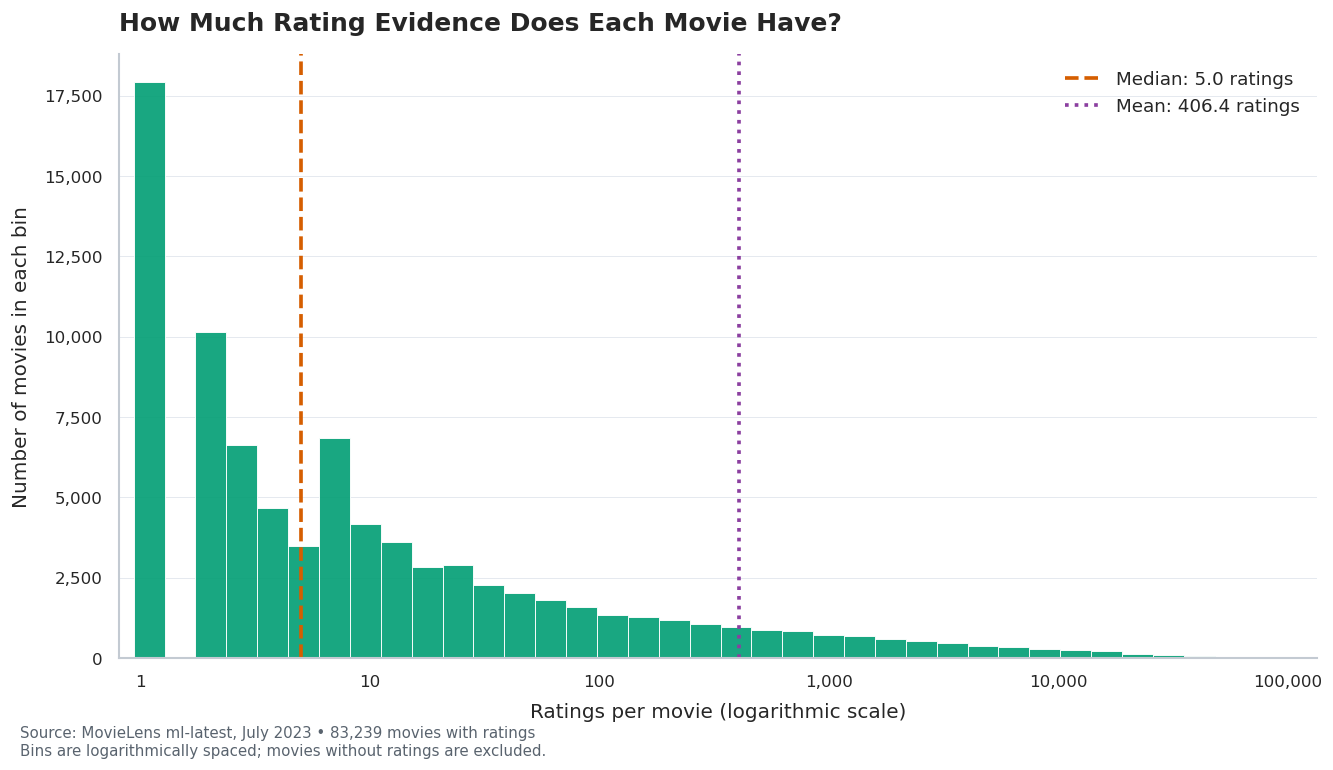

In [21]:
# Visualize ratings per movie
movie_counts = movie_rating_stats["rating_count"].to_numpy()

movie_bins = np.geomspace(
    0.5,
    movie_counts.max() + 0.5,
    num=41,
)

fig, ax = plt.subplots(figsize=(11, 6))

ax.hist(
    movie_counts,
    bins=movie_bins,
    color="#009E73",
    edgecolor="white",
    linewidth=0.6,
    alpha=0.9,
)

median_count = np.median(movie_counts)
mean_count = np.mean(movie_counts)

ax.axvline(
    median_count,
    color="#D55E00",
    linestyle="--",
    linewidth=2.2,
    label=f"Median: {median_count:,.1f} ratings",
)

ax.axvline(
    mean_count,
    color="#8B3FA0",
    linestyle=":",
    linewidth=2.2,
    label=f"Mean: {mean_count:,.1f} ratings",
)

ax.set_xscale("log")
ax.set_xlim(0.8, movie_counts.max() * 1.1)

tick_candidates = [1, 10, 100, 1_000, 10_000, 100_000, 1_000_000]
ax.set_xticks([
    value for value in tick_candidates
    if value <= movie_counts.max() * 1.1
])

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda value, _: f"{value:,.0f}")
)
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda value, _: f"{value:,.0f}")
)

ax.set_title("How Much Rating Evidence Does Each Movie Have?", loc="left")
ax.set_xlabel("Ratings per movie (logarithmic scale)")
ax.set_ylabel("Number of movies in each bin")

ax.set_axisbelow(True)
ax.grid(axis="x", visible=False, which="both")
ax.legend(frameon=False)

sns.despine(ax=ax)

fig.text(
    0.01,
    -0.04,
    f"Source: MovieLens ml-latest, July 2023 • "
    f"{len(movie_counts):,} movies with ratings\n"
    "Bins are logarithmically spaced; movies without ratings are excluded.",
    fontsize=9,
    color="#59636E",
)

plt.show()

In [22]:
# Measure movies with limited evidence
for threshold in [5, 20, 100]:
    movie_count = (movie_counts < threshold).sum()
    movie_share = movie_count / len(movie_counts) * 100

    print(
        f"Rated movies with fewer than {threshold} ratings: "
        f"{movie_count:,} ({movie_share:.2f}%)"
    )

movies_without_ratings = (
    ~movies["movieId"].isin(movie_rating_stats["movieId"])
).sum()

print(f"\nMetadata movies without ratings: {movies_without_ratings:,}")
print(f"Highest rating count for one movie: {movie_counts.max():,}")

Rated movies with fewer than 5 ratings: 39,366 (47.29%)
Rated movies with fewer than 20 ratings: 59,813 (71.86%)
Rated movies with fewer than 100 ratings: 70,986 (85.28%)

Metadata movies without ratings: 3,298
Highest rating count for one movie: 122,296


In [23]:
# Identify the ten most-rated movies
most_rated_movies = (
    movie_rating_stats.nlargest(10, "rating_count")
    .merge(
        movies[["movieId", "title"]],
        on="movieId",
        how="left",
        validate="many_to_one",
    )
)

display(
    most_rated_movies[
        ["title", "rating_count", "mean_rating"]
    ].style.format({
        "rating_count": "{:,.0f}",
        "mean_rating": "{:.2f}",
    }).hide(axis="index")
)

title,rating_count,mean_rating
"Shawshank Redemption, The (1994)","122,296",4.42
Forrest Gump (1994),"113,581",4.07
Pulp Fiction (1994),"108,756",4.19
"Matrix, The (1999)","107,056",4.16
"Silence of the Lambs, The (1991)","101,802",4.15
Star Wars: Episode IV - A New Hope (1977),"97,202",4.09
Fight Club (1999),"86,207",4.24
Schindler's List (1993),"84,232",4.24
Jurassic Park (1993),"83,026",3.69
Star Wars: Episode V - The Empire Strikes Back (1980),"80,200",4.12


### 5.4 Average Rating Versus Number of Ratings

A movie with a 5-star average from two ratings has less supporting
evidence than a movie with the same average from thousands of ratings.
We compare each movie's average rating with its number of ratings.
Each point represents one movie.
Colour distinguishes movies with fewer than 100 ratings from those
with at least 100. This is an illustrative threshold, not a rule for
removing movies or a guarantee of rating reliability.

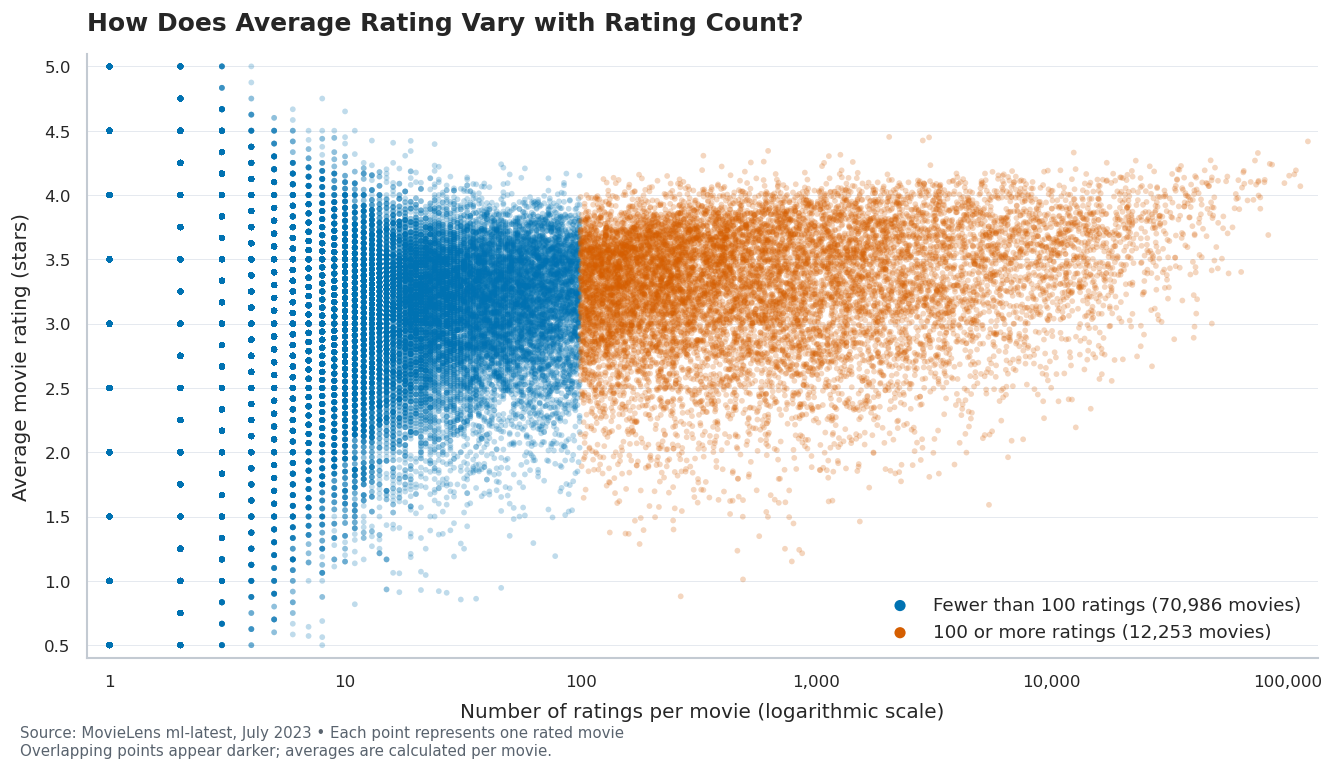

In [24]:
fig, ax = plt.subplots(figsize=(11, 6))

groups = [
    (
        movie_rating_stats["rating_count"] < 100,
        "#0072B2",
        "Fewer than 100 ratings",
    ),
    (
        movie_rating_stats["rating_count"] >= 100,
        "#D55E00",
        "100 or more ratings",
    ),
]

for mask, color, label in groups:
    group = movie_rating_stats.loc[mask]

    ax.scatter(
        group["rating_count"],
        group["mean_rating"],
        s=12,
        color=color,
        alpha=0.25,
        edgecolors="none",
        rasterized=True,
        label=f"{label} ({len(group):,} movies)",
    )

ax.set_xscale("log")

tick_candidates = [1, 10, 100, 1_000, 10_000, 100_000, 1_000_000]
max_count = movie_rating_stats["rating_count"].max()

ax.set_xticks([
    value for value in tick_candidates
    if value <= max_count * 1.1
])
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda value, _: f"{value:,.0f}")
)

ax.set_xlim(0.8, max_count * 1.1)
ax.set_ylim(0.4, 5.1)
ax.set_yticks(np.arange(0.5, 5.1, 0.5))

ax.set_title(
    "How Does Average Rating Vary with Rating Count?",
    loc="left",
)
ax.set_xlabel("Number of ratings per movie (logarithmic scale)")
ax.set_ylabel("Average movie rating (stars)")

ax.set_axisbelow(True)
ax.grid(axis="x", visible=False, which="both")

# Opaque legend markers make the colours easier to identify.
legend = ax.legend(frameon=False, loc="lower right")
for handle in legend.legend_handles:
    handle.set_alpha(1)
    handle.set_sizes([45])

sns.despine(ax=ax)

fig.text(
    0.01,
    -0.04,
    "Source: MovieLens ml-latest, July 2023 • "
    "Each point represents one rated movie\n"
    "Overlapping points appear darker; averages are calculated per movie.",
    fontsize=9,
    color="#59636E",
)

plt.show()

In [25]:
# Compare movies by rating-count range
count_ranges = pd.cut(
    movie_rating_stats["rating_count"],
    bins=[0, 9, 99, 999, np.inf],
    labels=["1–9", "10–99", "100–999", "1,000+"],
)

evidence_summary = (
    movie_rating_stats
    .groupby(count_ranges, observed=True)
    .agg(
        movie_count=("movieId", "size"),
        median_movie_average=("mean_rating", "median"),
        lowest_movie_average=("mean_rating", "min"),
        highest_movie_average=("mean_rating", "max"),
    )
)

evidence_summary.index.name = "Ratings per movie"

display(
    evidence_summary.style.format({
        "movie_count": "{:,.0f}",
        "median_movie_average": "{:.2f}",
        "lowest_movie_average": "{:.2f}",
        "highest_movie_average": "{:.2f}",
    })
)

,movie_count,median_movie_average,lowest_movie_average,highest_movie_average
Ratings per movie,,,,
1–9,"51,218",3.00,0.50,5.00
10–99,"19,768",3.15,0.82,4.65
100–999,"7,789",3.31,0.88,4.34
"1,000+","4,464",3.47,1.46,4.45


## 6. Define Model Inputs and Target

We will use matrix factorization to learn patterns from user–movie
rating interactions.

| Column | Role | Meaning |
|---|---|---|
| userId | Input identifier | Identifies the user |
| movieId | Input identifier | Identifies the movie |
| rating | Target | The observed rating to predict |
| timestamp | Split information | Available for a chronological split |

User and movie IDs are categorical identifiers. Their numerical
ordering has no meaning: movie 200 is not “twice” movie 100.

The model will learn a vector for each training user and movie.
Interactions between these vectors, together with rating biases,
will produce a predicted rating.

Titles and genres help explain our examples but are not inputs
to this initial model.

We will create ID-to-index mappings after splitting the data,
using training users and movies only. Unseen users or movies
will require a fallback prediction.

In [26]:
# Declare the columns
INPUT_COLUMNS = ["userId", "movieId"]
TARGET_COLUMN = "rating"
TIME_COLUMN = "timestamp"

required_columns = INPUT_COLUMNS + [TARGET_COLUMN, TIME_COLUMN]

missing_columns = [
    column for column in required_columns
    if column not in ratings.columns
]

if missing_columns:
    raise ValueError(f"Required columns are missing: {missing_columns}")

column_roles = pd.DataFrame({
    "Column": required_columns,
    "Role": [
        "Input identifier",
        "Input identifier",
        "Prediction target",
        "Available for chronological splitting",
    ],
    "Data type": [
        str(ratings[column].dtype)
        for column in required_columns
    ],
})

display(column_roles)

,Column,Role,Data type
0,userId,Input identifier,int32
1,movieId,Input identifier,int32
2,rating,Prediction target,float32
3,timestamp,Available for chronological splitting,int64


In [27]:
# Show example inputs and their targets
learning_examples = (
    ratings[INPUT_COLUMNS + [TARGET_COLUMN]]
    .sample(n=5, random_state=SEED)
    .reset_index(drop=True)
)

display(learning_examples)

,userId,movieId,rating
0,23474,8636,2.0
1,327932,480,2.0
2,32973,5481,0.5
3,174379,7325,3.5
4,197873,2467,4.5


## 7. Split the Data

We randomly divide observed ratings into three sets:

- Training (80%): learn model parameters.
- Validation (10%): choose model settings and when to stop training.
- Test (10%): evaluate the final selected model once.

The split is reproducible using a fixed random seed.

Some validation or test users and movies may not appear in training.
We will measure this coverage and later use a fallback for unseen IDs.

This random split evaluates held-out ratings, rather than future
performance. A chronological split would answer a different question.

In [28]:
# Verify that ratings are ready
required_for_training = ["userId", "movieId", "rating", "timestamp"]

if ratings[required_for_training].isna().any().any():
    raise ValueError("Resolve missing required values before splitting.")

if not ratings["rating"].isin(np.arange(0.5, 5.1, 0.5)).all():
    raise ValueError("Resolve invalid ratings before splitting.")

if ratings.duplicated(["userId", "movieId"]).any():
    raise ValueError(
        "Resolve repeated user–movie pairs before splitting "
        "to prevent the same pair appearing in multiple sets."
    )

print("Ratings are ready for splitting.")

Ratings are ready for splitting.


In [29]:
# Create the three sets
split_rng = np.random.default_rng(SEED)
shuffled_positions = split_rng.permutation(len(ratings))

train_end = int(len(ratings) * 0.80)
validation_end = train_end + int(len(ratings) * 0.10)

train_ratings = (
    ratings.iloc[shuffled_positions[:train_end]]
    .reset_index(drop=True)
)

validation_ratings = (
    ratings.iloc[shuffled_positions[train_end:validation_end]]
    .reset_index(drop=True)
)

test_ratings = (
    ratings.iloc[shuffled_positions[validation_end:]]
    .reset_index(drop=True)
)

# Release the temporary row-position array.
del shuffled_positions

assert (
    len(train_ratings)
    + len(validation_ratings)
    + len(test_ratings)
    == len(ratings)
)

In [30]:
# Display split sizes
split_summary = pd.DataFrame({
    "Set": ["Training", "Validation", "Test"],
    "Ratings": [
        len(train_ratings),
        len(validation_ratings),
        len(test_ratings),
    ],
})

split_summary["Share (%)"] = (
    split_summary["Ratings"] / len(ratings) * 100
)

display(
    split_summary.style.format({
        "Ratings": "{:,.0f}",
        "Share (%)": "{:.2f}%",
    }).hide(axis="index")
)

Set,Ratings,Share (%)
Training,"27,065,729",80.00%
Validation,"3,383,216",10.00%
Test,"3,383,217",10.00%


In [31]:
# Check coverage of training users and movies
training_user_ids = pd.Index(train_ratings["userId"].unique())
training_movie_ids = pd.Index(train_ratings["movieId"].unique())

coverage_rows = []

for name, frame in [
    ("Validation", validation_ratings),
    ("Test", test_ratings),
]:
    known_user = frame["userId"].isin(training_user_ids)
    known_movie = frame["movieId"].isin(training_movie_ids)
    both_known = known_user & known_movie

    coverage_rows.append({
        "Set": name,
        "Ratings": len(frame),
        "Both IDs seen in training (%)": both_known.mean() * 100,
        "Ratings with unseen user": (~known_user).sum(),
        "Ratings with unseen movie": (~known_movie).sum(),
        "Ratings needing fallback": (~both_known).sum(),
    })

coverage_summary = pd.DataFrame(coverage_rows)

display(
    coverage_summary.style.format({
        "Ratings": "{:,.0f}",
        "Both IDs seen in training (%)": "{:.2f}%",
        "Ratings with unseen user": "{:,.0f}",
        "Ratings with unseen movie": "{:,.0f}",
        "Ratings needing fallback": "{:,.0f}",
    }).hide(axis="index")
)

del known_user, known_movie, both_known

Set,Ratings,Both IDs seen in training (%),Ratings with unseen user,Ratings with unseen movie,Ratings needing fallback
Validation,"3,383,216",99.90%,"1,173","2,299","3,469"
Test,"3,383,217",99.90%,"1,200","2,242","3,439"


## 8. Build a Baseline

Our baseline predicts the average training rating for every user–movie pair.

It does not learn individual preferences. The matrix factorization
model should improve on this simple prediction.

We evaluate the baseline on validation data using:
- MAE: average absolute prediction error, in stars.
- RMSE: prediction error in stars, with larger errors penalized more.

The test set remains reserved for final evaluation.

In [32]:
# Calculate the baseline prediction
# Accumulate in float64 for numerical precision.
baseline_rating = np.mean(
    train_ratings["rating"].to_numpy(),
    dtype=np.float64,
)

print(f"Baseline prediction: {baseline_rating:.3f} stars")

Baseline prediction: 3.543 stars


In [33]:
# Evaluate on validation data
validation_actual = validation_ratings["rating"].to_numpy(
    dtype=np.float64
)

baseline_errors = validation_actual - baseline_rating

baseline_mae = np.mean(np.abs(baseline_errors))
baseline_rmse = np.sqrt(np.mean(baseline_errors ** 2))

baseline_results = pd.DataFrame({
    "Model": ["Training mean baseline"],
    "Validation MAE (stars)": [baseline_mae],
    "Validation RMSE (stars)": [baseline_rmse],
})

display(
    baseline_results.style.format({
        "Validation MAE (stars)": "{:.4f}",
        "Validation RMSE (stars)": "{:.4f}",
    }).hide(axis="index")
)

del validation_actual, baseline_errors

Model,Validation MAE (stars),Validation RMSE (stars)
Training mean baseline,0.8429,1.0640


In [34]:
# Preview baseline predictions
baseline_examples = (
    validation_ratings[["userId", "movieId", "rating"]]
    .sample(n=5, random_state=SEED)
    .rename(columns={"rating": "actual_rating"})
    .reset_index(drop=True)
)

baseline_examples["predicted_rating"] = baseline_rating
baseline_examples["absolute_error"] = (
    baseline_examples["actual_rating"]
    - baseline_examples["predicted_rating"]
).abs()

display(
    baseline_examples.style.format({
        "actual_rating": "{:.1f}",
        "predicted_rating": "{:.3f}",
        "absolute_error": "{:.3f}",
    }).hide(axis="index")
)

userId,movieId,actual_rating,predicted_rating,absolute_error
235694,3039,3.5,3.543,0.043
38805,762,2.0,3.543,1.543
89730,4226,4.5,3.543,0.957
180767,134853,5.0,3.543,1.457
163748,1,0.5,3.543,3.043


## 9. Train a Matrix Factorization Model

### 9.1 Encode User and Movie Identifiers

Embedding layers require consecutive integer indices.

We build mappings from training IDs only:
- Training users map to indices 0 through n_users − 1.
- Training movies map to indices 0 through n_movies − 1.
- Unseen validation IDs receive −1.

The indices identify embedding rows; their numerical order has
no meaning.

Validation rows with unseen IDs will receive the training-mean
fallback. We retain them for evaluation but do not pass −1
into the embedding layers.

In [35]:
# Create mappings from training data
user_index = pd.Index(
    np.sort(train_ratings["userId"].unique())
)
movie_index = pd.Index(
    np.sort(train_ratings["movieId"].unique())
)

n_users = len(user_index)
n_movies = len(movie_index)

print(f"Training users: {n_users:,}")
print(f"Training movies: {n_movies:,}")

Training users: 328,932
Training movies: 79,200


In [36]:
# Encode training inputs
train_user_indices = user_index.get_indexer(
    train_ratings["userId"]
).astype(np.int32)

train_movie_indices = movie_index.get_indexer(
    train_ratings["movieId"]
).astype(np.int32)

train_targets = train_ratings["rating"].to_numpy(
    dtype=np.float32
)

assert (train_user_indices >= 0).all()
assert (train_movie_indices >= 0).all()

print(f"Encoded training examples: {len(train_targets):,}")

Encoded training examples: 27,065,729


In [37]:
# Encode validation inputs
validation_user_indices = user_index.get_indexer(
    validation_ratings["userId"]
).astype(np.int32)

validation_movie_indices = movie_index.get_indexer(
    validation_ratings["movieId"]
).astype(np.int32)

validation_targets = validation_ratings["rating"].to_numpy(
    dtype=np.float32
)

validation_known_mask = (
    (validation_user_indices >= 0)
    & (validation_movie_indices >= 0)
)

print(
    "Validation examples with both IDs known: "
    f"{validation_known_mask.sum():,}"
)
print(
    "Validation examples requiring fallback: "
    f"{(~validation_known_mask).sum():,}"
)

Validation examples with both IDs known: 3,379,747
Validation examples requiring fallback: 3,469


In [38]:
# Preview the encoding
encoding_preview = pd.DataFrame({
    "original_userId": train_ratings["userId"].iloc[:5].to_numpy(),
    "user_index": train_user_indices[:5],
    "original_movieId": train_ratings["movieId"].iloc[:5].to_numpy(),
    "movie_index": train_movie_indices[:5],
    "rating": train_targets[:5],
})

display(encoding_preview)

,original_userId,user_index,original_movieId,movie_index,rating
0,58003,57657,3006,2914,3.5
1,137666,136797,3159,3066,3.0
2,205621,204355,2539,2448,3.5
3,127601,126789,2706,2614,4.0
4,206659,205381,168344,42082,3.0


<b> Matrix Factorization Model </b>

Now we’ll build and train the matrix factorization model.

The prediction for user **u** and item **m** is:

$$
\hat{r}_{u,m} = \mu + b_u + b_m + p_u^\top q_m
$$

Where:

- **μ** — global mean rating  
- **bᵤ** — user bias  
- **bₘ** — movie bias  
- **pᵤ** — latent factor vector for user *u*  
- **qₘ** — latent factor vector for movie *m*  
- **pᵤᵀ qₘ** — interaction term capturing how user preferences align with movie attributes

This model combines global tendencies, user tendencies, movie tendencies, and learned latent interactions to produce a predicted rating.ce a predicted rating.


In [39]:
# Import TensorFlow
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
keras.utils.set_random_seed(SEED)
print("TensorFlow version:", tf.__version__)
print("Available GPUs:", tf.config.list_physical_devices("GPU"))
# If TensorFlow is missing, install it in a separate cell and restart the kernel: 
# %pip install tensorflow


TensorFlow version: 2.15.1
Available GPUs: []


<b> Modeling </b>

In [40]:
EMBEDDING_DIM = 32
LEARNING_RATE = 0.001

user_input = keras.Input(
    shape=(1,), dtype="int32", name="user"
)
movie_input = keras.Input(
    shape=(1,), dtype="int32", name="movie"
)

user_vector = layers.Flatten()(
    layers.Embedding(
        n_users,
        EMBEDDING_DIM,
        embeddings_initializer=keras.initializers.RandomNormal(
            stddev=0.05, seed=SEED
        ),
        name="user_embedding",
    )(user_input)
)

movie_vector = layers.Flatten()(
    layers.Embedding(
        n_movies,
        EMBEDDING_DIM,
        embeddings_initializer=keras.initializers.RandomNormal(
            stddev=0.05, seed=SEED + 1
        ),
        name="movie_embedding",
    )(movie_input)
)

user_bias = layers.Flatten()(
    layers.Embedding(
        n_users, 1,
        embeddings_initializer="zeros",
        name="user_bias",
    )(user_input)
)

movie_bias = layers.Flatten()(
    layers.Embedding(
        n_movies, 1,
        embeddings_initializer="zeros",
        name="movie_bias",
    )(movie_input)
)

interaction = layers.Dot(axes=1)(
    [user_vector, movie_vector]
)

rating_adjustment = layers.Add()(
    [interaction, user_bias, movie_bias]
)

prediction = layers.Rescaling(
    scale=1.0,
    offset=float(baseline_rating),
    name="predicted_rating",
)(rating_adjustment)

model = keras.Model(
    inputs={"user": user_input, "movie": movie_input},
    outputs=prediction,
    name="movie_rating_matrix_factorization",
)

model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=LEARNING_RATE
    ),
    loss="mse",
    metrics=[
        keras.metrics.MeanAbsoluteError(name="mae"),
        keras.metrics.RootMeanSquaredError(name="rmse"),
    ],
)

model.summary()


Model: "movie_rating_matrix_factorization"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 user (InputLayer)           [(None, 1)]                  0         []                            
                                                                                                  
 movie (InputLayer)          [(None, 1)]                  0         []                            
                                                                                                  
 user_embedding (Embedding)  (None, 1, 32)                1052582   ['user[0][0]']                
                                                          4                                       
                                                                                                  
 movie_embedding (Embedding  (None, 1, 32)                2534400

In [41]:
# Batching preparation
BATCH_SIZE = 8192

train_dataset = tf.data.Dataset.from_tensor_slices((
    {
        "user": train_user_indices[:, None],
        "movie": train_movie_indices[:, None],
    },
    train_targets[:, None],
))

train_dataset = (
    train_dataset
    .shuffle(
        buffer_size=100_000,
        seed=SEED,
        reshuffle_each_iteration=True,
    )
    .batch(BATCH_SIZE)
    .prefetch(1)
)

if not validation_known_mask.any():
    raise ValueError("No validation examples have both IDs known.")

validation_dataset = tf.data.Dataset.from_tensor_slices((
    {
        "user": validation_user_indices[
            validation_known_mask
        ][:, None],
        "movie": validation_movie_indices[
            validation_known_mask
        ][:, None],
    },
    validation_targets[validation_known_mask][:, None],
))

validation_dataset = (
    validation_dataset
    .batch(BATCH_SIZE)
    .prefetch(1)
)

In [42]:
# Measure performance before learning
initial_metrics = model.evaluate(
    validation_dataset,
    return_dict=True,
    verbose=0,
)

print("Before training — validation rows with known IDs")
print(f"MAE:  {initial_metrics['mae']:.4f} stars")
print(f"RMSE: {initial_metrics['rmse']:.4f} stars")


Before training — validation rows with known IDs
MAE:  0.8428 stars
RMSE: 1.0638 stars


In [43]:
# Train and record progress
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_rmse",
    mode="min",
    patience=2,
    restore_best_weights=True,
    verbose=1,
)

history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=10,
    callbacks=[
        early_stopping,
        keras.callbacks.TerminateOnNaN(),
    ],
    verbose=1,
)

Epoch 1/10
3304/3304 [==============================] - 517s 156ms/step - loss: 0.8232 - mae: 0.6931 - rmse: 0.9073 - val_loss: 0.6902 - val_mae: 0.6279 - val_rmse: 0.8308
Epoch 2/10
3304/3304 [==============================] - 517s 156ms/step - loss: 0.6292 - mae: 0.5976 - rmse: 0.7932 - val_loss: 0.6361 - val_mae: 0.6011 - val_rmse: 0.7976
Epoch 3/10
3304/3304 [==============================] - 522s 158ms/step - loss: 0.5546 - mae: 0.5591 - rmse: 0.7447 - val_loss: 0.6218 - val_mae: 0.5939 - val_rmse: 0.7886
Epoch 4/10
3304/3304 [==============================] - 520s 157ms/step - loss: 0.5071 - mae: 0.5333 - rmse: 0.7121 - val_loss: 0.6226 - val_mae: 0.5940 - val_rmse: 0.7890
Epoch 5/10
3304/3304 [==============================] - 520s 158ms/step - loss: 0.4760 - mae: 0.5154 - rmse: 0.6899 - val_loss: 0.6285 - val_mae: 0.5965 - val_rmse: 0.7928
Epoch 5: early stopping


In [44]:
# Display the training record
learning_history = pd.DataFrame(history.history)
learning_history.index = np.arange(
    1, len(learning_history) + 1
)
learning_history.index.name = "Epoch"

display(learning_history.style.format("{:.4f}"))

,loss,mae,rmse,val_loss,val_mae,val_rmse
Epoch,,,,,,
1,0.8232,0.6931,0.9073,0.6902,0.6279,0.8308
2,0.6292,0.5976,0.7932,0.6361,0.6011,0.7976
3,0.5546,0.5591,0.7447,0.6218,0.5939,0.7886
4,0.5071,0.5333,0.7121,0.6226,0.5940,0.7890
5,0.4760,0.5154,0.6899,0.6285,0.5965,0.7928


## 10. Observe How Learning Happens

We track prediction errors over training epochs.

Training error measures performance while the model updates its parameters.
Validation error measures performance on held-out ratings with known IDs.

If training error keeps decreasing while validation error increases,
the model may be starting to overfit.

We select the epoch with the lowest validation RMSE.
The test set remains untouched.

In [45]:
# Identify the best epoch
best_epoch = int(learning_history["val_rmse"].idxmin())

print(f"Best validation epoch: {best_epoch}")
print(
    f"Validation MAE: "
    f"{learning_history.loc[best_epoch, 'val_mae']:.4f} stars"
)
print(
    f"Validation RMSE: "
    f"{learning_history.loc[best_epoch, 'val_rmse']:.4f} stars"
)

Best validation epoch: 3
Validation MAE: 0.5939 stars
Validation RMSE: 0.7886 stars


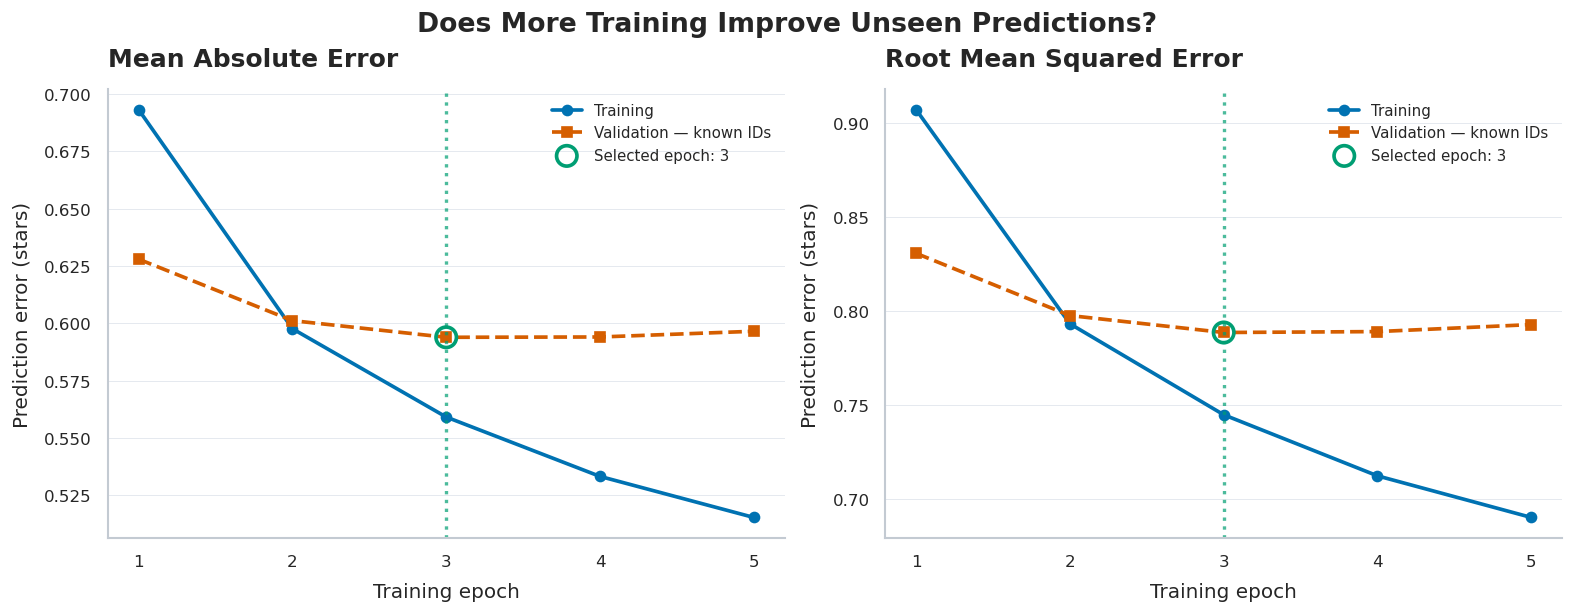

In [46]:
# Plot the learning curves
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

epochs = learning_history.index.to_numpy()

for ax, metric, title in [
    (axes[0], "mae", "Mean Absolute Error"),
    (axes[1], "rmse", "Root Mean Squared Error"),
]:
    ax.plot(
        epochs,
        learning_history[metric],
        color="#0072B2",
        marker="o",
        linewidth=2.2,
        label="Training",
    )

    ax.plot(
        epochs,
        learning_history[f"val_{metric}"],
        color="#D55E00",
        marker="s",
        linestyle="--",
        linewidth=2.2,
        label="Validation — known IDs",
    )

    best_value = learning_history.loc[
        best_epoch, f"val_{metric}"
    ]

    ax.scatter(
        best_epoch,
        best_value,
        s=150,
        facecolors="none",
        edgecolors="#009E73",
        linewidths=2.2,
        zorder=5,
        label=f"Selected epoch: {best_epoch}",
    )

    ax.axvline(
        best_epoch,
        color="#009E73",
        linestyle=":",
        alpha=0.7,
    )

    ax.set_title(title, loc="left")
    ax.set_xlabel("Training epoch")
    ax.set_ylabel("Prediction error (stars)")
    ax.set_xticks(epochs)
    ax.grid(axis="x", visible=False)
    ax.legend(frameon=False, fontsize=9)
    sns.despine(ax=ax)

fig.suptitle(
    "Does More Training Improve Unseen Predictions?",
    fontsize=16,
    fontweight="bold",
)

plt.show()

In [47]:
# Predict validation ratings
validation_predictions = np.full(
    len(validation_targets),
    baseline_rating,
    dtype=np.float64,
)

known_predictions = model.predict(
    {
        "user": validation_user_indices[
            validation_known_mask
        ][:, None],
        "movie": validation_movie_indices[
            validation_known_mask
        ][:, None],
    },
    batch_size=BATCH_SIZE,
    verbose=1,
).ravel()

validation_predictions[validation_known_mask] = known_predictions

del known_predictions

print(
    f"Model predictions: {validation_known_mask.sum():,}"
)
print(
    f"Training-mean fallback predictions: "
    f"{(~validation_known_mask).sum():,}"
)

413/413 [==============================] - 3s 7ms/step
Model predictions: 3,379,747
Training-mean fallback predictions: 3,469


In [48]:
# Calculate comparable metrics
def rating_metrics(actual, predicted):
    errors = (
        np.asarray(actual, dtype=np.float64)
        - np.asarray(predicted, dtype=np.float64)
    )

    return {
        "MAE": np.mean(np.abs(errors)),
        "RMSE": np.sqrt(np.mean(errors ** 2)),
    }


model_validation_metrics = rating_metrics(
    validation_targets,
    validation_predictions,
)

validation_comparison = pd.DataFrame({
    "Model": [
        "Training mean baseline",
        "Matrix factorization + fallback",
    ],
    "MAE": [
        baseline_mae,
        model_validation_metrics["MAE"],
    ],
    "RMSE": [
        baseline_rmse,
        model_validation_metrics["RMSE"],
    ],
})

display(
    validation_comparison.style.format({
        "MAE": "{:.4f}",
        "RMSE": "{:.4f}",
    }).hide(axis="index")
)

Model,MAE,RMSE
Training mean baseline,0.8429,1.0640
Matrix factorization + fallback,0.5943,0.7893


In [49]:
# Measure improvement
for metric, baseline_value in [
    ("MAE", baseline_mae),
    ("RMSE", baseline_rmse),
]:
    model_value = model_validation_metrics[metric]

    improvement = (
        (baseline_value - model_value)
        / baseline_value
        * 100
    )

    print(
        f"{metric} reduction versus baseline: "
        f"{improvement:.2f}%"
    )

MAE reduction versus baseline: 29.49%
RMSE reduction versus baseline: 25.82%


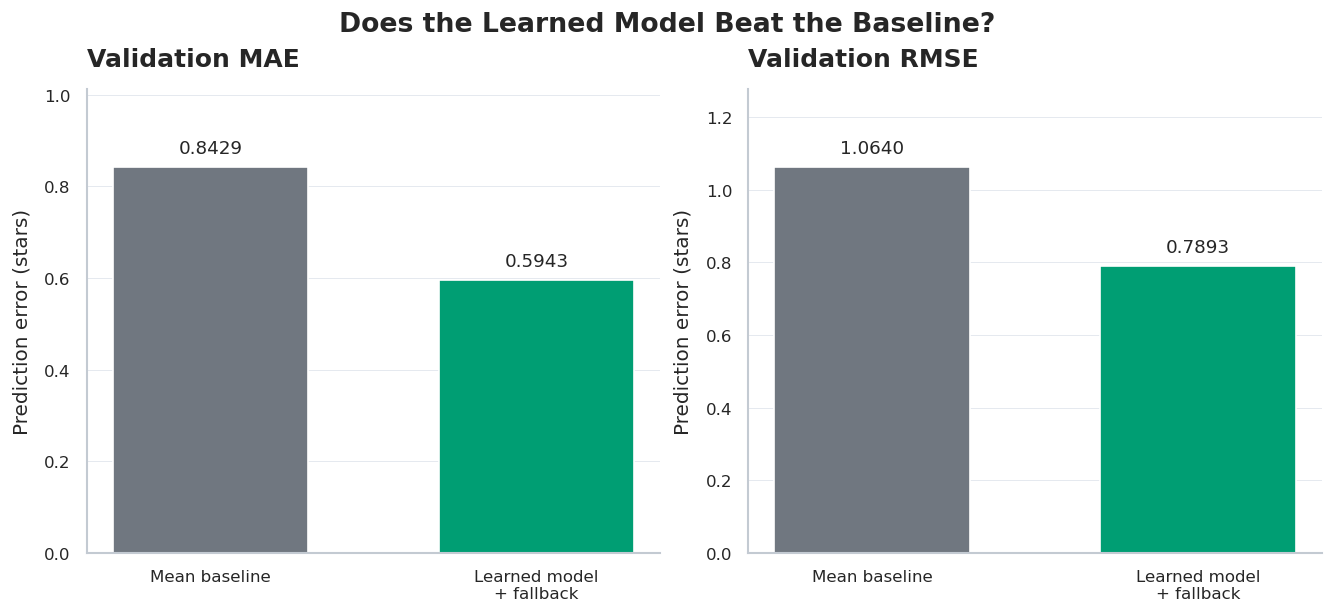

In [50]:
# Visualize the comparison
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for ax, metric in zip(axes, ["MAE", "RMSE"]):
    values = validation_comparison[metric].to_numpy()

    bars = ax.bar(
        ["Mean baseline", "Learned model\n+ fallback"],
        values,
        color=["#707780", "#009E73"],
        width=0.6,
    )

    ax.bar_label(
        bars,
        labels=[f"{value:.4f}" for value in values],
        padding=6,
        fontsize=11,
    )

    ax.set_title(f"Validation {metric}", loc="left")
    ax.set_ylabel("Prediction error (stars)")
    ax.set_ylim(0, values.max() * 1.20)
    ax.grid(axis="x", visible=False)
    ax.set_axisbelow(True)

    sns.despine(ax=ax)

fig.suptitle(
    "Does the Learned Model Beat the Baseline?",
    fontsize=16,
    fontweight="bold",
)

plt.show()

## 11. Evaluate Unseen Test Ratings

We evaluate the selected model on the held-out test set.

Both the baseline and learned model are evaluated on the same rows.
Unknown users or movies receive the training-mean fallback.

We report MAE and RMSE in stars and inspect randomly selected predictions.

These results measure held-out rating prediction under a random split.
They do not measure future performance or recommendation-ranking quality.

In [51]:
# Encode test IDs
test_user_indices = user_index.get_indexer(
    test_ratings["userId"]
).astype(np.int32)

test_movie_indices = movie_index.get_indexer(
    test_ratings["movieId"]
).astype(np.int32)

test_targets = test_ratings["rating"].to_numpy(
    dtype=np.float32
)

test_known_mask = (
    (test_user_indices >= 0)
    & (test_movie_indices >= 0)
)

print(f"Test ratings: {len(test_targets):,}")
print(f"Ratings with both IDs known: {test_known_mask.sum():,}")
print(f"Ratings requiring fallback: {(~test_known_mask).sum():,}")

Test ratings: 3,383,217
Ratings with both IDs known: 3,379,778
Ratings requiring fallback: 3,439


In [52]:
# Predict test ratings
test_predictions = np.full(
    len(test_targets),
    baseline_rating,
    dtype=np.float64,
)

if test_known_mask.any():
    test_predictions[test_known_mask] = model.predict(
        {
            "user": test_user_indices[test_known_mask][:, None],
            "movie": test_movie_indices[test_known_mask][:, None],
        },
        batch_size=BATCH_SIZE,
        verbose=1,
    ).ravel()

assert np.isfinite(test_predictions).all()

413/413 [==============================] - 3s 7ms/step


In [53]:
# Compare final test performance
test_baseline_metrics = rating_metrics(
    test_targets,
    baseline_rating,
)

test_model_metrics = rating_metrics(
    test_targets,
    test_predictions,
)

test_comparison = pd.DataFrame({
    "Model": [
        "Training mean baseline",
        "Matrix factorization + fallback",
    ],
    "Test MAE": [
        test_baseline_metrics["MAE"],
        test_model_metrics["MAE"],
    ],
    "Test RMSE": [
        test_baseline_metrics["RMSE"],
        test_model_metrics["RMSE"],
    ],
})

display(
    test_comparison.style.format({
        "Test MAE": "{:.4f}",
        "Test RMSE": "{:.4f}",
    }).hide(axis="index")
)

for metric in ["MAE", "RMSE"]:
    improvement = (
        (
            test_baseline_metrics[metric]
            - test_model_metrics[metric]
        )
        / test_baseline_metrics[metric]
        * 100
    )

    print(f"Test {metric} reduction: {improvement:.2f}%")

Model,Test MAE,Test RMSE
Training mean baseline,0.8427,1.0639
Matrix factorization + fallback,0.5936,0.7886


Test MAE reduction: 29.56%
Test RMSE reduction: 25.87%


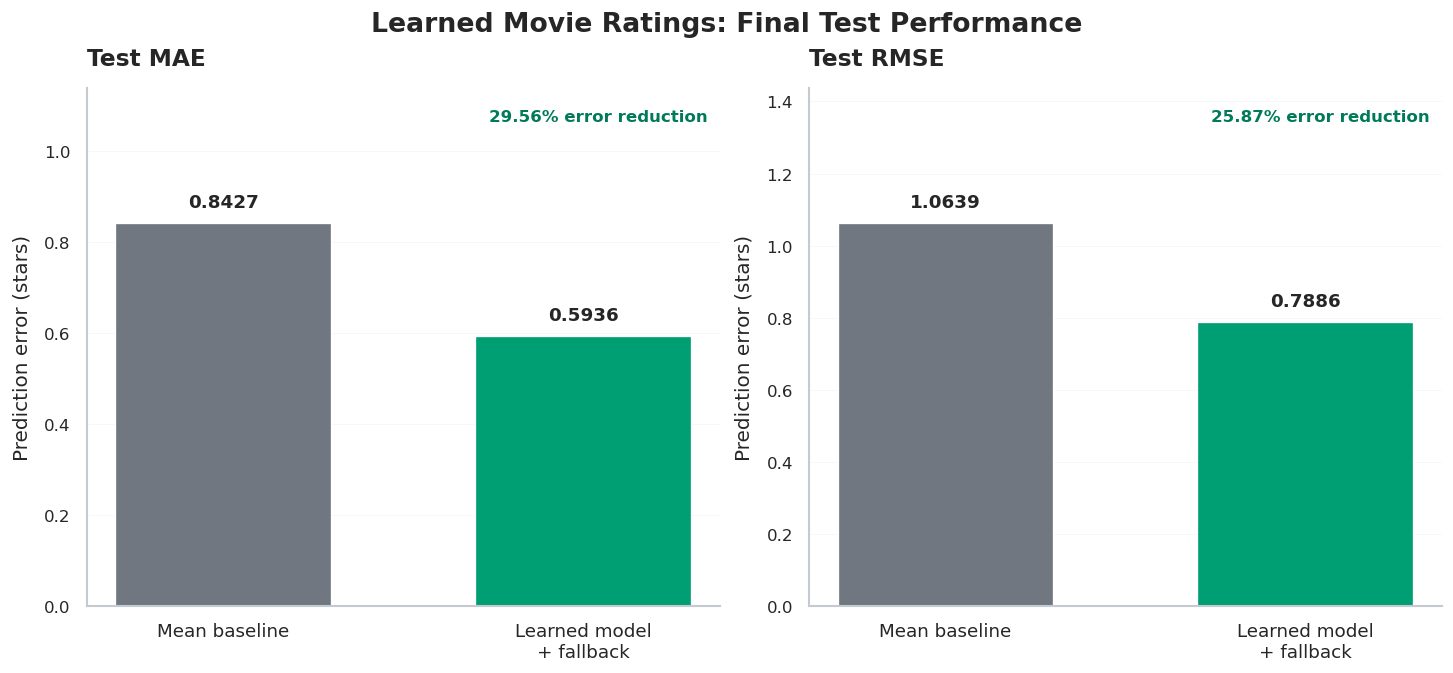

In [57]:
# Visualize final test performance
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

labels = ["Mean baseline", "Learned model\n+ fallback"]
colors = ["#707780", "#009E73"]

for ax, metric in zip(axes, ["MAE", "RMSE"]):
    values = test_comparison[f"Test {metric}"].to_numpy()

    bars = ax.bar(
        labels,
        values,
        color=colors,
        width=0.6,
        edgecolor="white",
        linewidth=0.8,
    )

    ax.bar_label(
        bars,
        labels=[f"{value:.4f}" for value in values],
        padding=7,
        fontsize=11,
        fontweight="bold",
    )

    reduction = (values[0] - values[1]) / values[0] * 100

    ax.set_title(
        f"Test {metric}",
        loc="left",
        fontsize=14,
        fontweight="bold",
        pad=14,
    )

    ax.text(
        0.98,
        0.96,
        f"{reduction:.2f}% error reduction",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=10,
        color="#007A59",
        fontweight="bold",
    )

    ax.set_ylabel("Prediction error (stars)")
    ax.set_ylim(0, values.max() * 1.35)
    ax.set_axisbelow(True)
    ax.grid(axis="x", visible=False)
    ax.grid(axis="y", alpha=0.35)
    ax.tick_params(axis="x", labelsize=11)

    sns.despine(ax=ax)

fig.suptitle(
    "Learned Movie Ratings: Final Test Performance",
    fontsize=16,
    fontweight="bold",
)

# Save before showing the figure.
fig.savefig(
    "movielens_test_performance.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

In [54]:
# Inspect randomly selected predictions
example_rng = np.random.default_rng(SEED)

example_positions = example_rng.choice(
    len(test_ratings),
    size=min(10, len(test_ratings)),
    replace=False,
)

test_examples = (
    test_ratings.iloc[example_positions][
        ["userId", "movieId", "rating"]
    ]
    .rename(columns={"rating": "actual_rating"})
    .copy()
)

test_examples["predicted_rating"] = (
    test_predictions[example_positions]
)

test_examples["absolute_error"] = (
    test_examples["actual_rating"]
    - test_examples["predicted_rating"]
).abs()

test_examples["prediction_method"] = np.where(
    test_known_mask[example_positions],
    "Learned model",
    "Mean fallback",
)

test_examples = test_examples.merge(
    movies[["movieId", "title"]],
    on="movieId",
    how="left",
    validate="many_to_one",
)

display(
    test_examples[
        [
            "userId",
            "title",
            "actual_rating",
            "predicted_rating",
            "absolute_error",
            "prediction_method",
        ]
    ].style.format({
        "actual_rating": "{:.1f}",
        "predicted_rating": "{:.3f}",
        "absolute_error": "{:.3f}",
    }).hide(axis="index")
)

userId,title,actual_rating,predicted_rating,absolute_error,prediction_method
42110,Boiler Room (2000),3.5,3.209,0.291,Learned model
306139,Circle of Friends (1995),2.0,2.295,0.295,Learned model
123939,"Nightmare Before Christmas, The (1993)",4.0,3.857,0.143,Learned model
27533,Casper (1995),3.0,2.881,0.119,Learned model
47051,From Hell (2001),3.5,2.901,0.599,Learned model
68775,Eyes Wide Shut (1999),4.0,3.987,0.013,Learned model
62728,"Sixth Sense, The (1999)",4.0,4.390,0.390,Learned model
257237,The Revenant (2015),4.0,3.867,0.133,Learned model
56301,Stargate (1994),4.5,4.373,0.127,Learned model
90077,Shaun of the Dead (2004),3.0,3.681,0.681,Learned model


In [55]:
# Check predictions outside the rating scale
outside_scale = (
    (test_predictions < 0.5)
    | (test_predictions > 5.0)
)

print(
    "Raw predictions outside 0.5–5.0 stars: "
    f"{outside_scale.sum():,} "
    f"({outside_scale.mean() * 100:.2f}%)"
)

Raw predictions outside 0.5–5.0 stars: 35,840 (1.06%)


## 12. Findings and Limitations

### How the Model Learned

The model started with small random user and movie vectors,
zero rating biases, and the training mean as its starting point.

During training, it:
1. Predicted ratings for batches of user–movie pairs.
2. Compared predictions with observed training ratings.
3. Used prediction errors to update its vectors and biases.
4. Repeated this process across epochs.

The learned vectors represent patterns in rating interactions.
Their dimensions do not automatically correspond to named
properties such as “comedy preference” or “action preference.”

### Learning and Generalization

Validation RMSE reached its minimum at epoch 3. Further training
reduced training error while validation error increased slightly,
suggesting the beginning of overfitting.

Early stopping restored the selected weights.

The final test comparison measures whether the learned model
improved on predicting the same training-mean rating for everyone.
MAE describes average absolute error in stars; RMSE gives greater
weight to larger errors.

### Limitations

- The random split evaluates held-out ratings across the dataset's
  time period, rather than predictions of future ratings.
- Users and movies absent from training receive a mean fallback;
  the model cannot learn their individual vectors without examples.
- Users choose which movies to watch and rate. Observed ratings
  therefore do not represent every viewer or every possible pair.
- Movies and users with few ratings provide limited evidence.
- Raw model predictions can fall outside the 0.5–5.0 rating scale.
- Rating-prediction accuracy does not establish the quality of
  a ranked recommendation list.
- MovieLens ml-latest is a development dataset. This notebook uses
  the release generated on July 20, 2023.

In [56]:
# Summarize the findings
print("FINAL RESULTS")
print(f"Selected training epoch: {best_epoch}")

for metric in ["MAE", "RMSE"]:
    baseline_value = test_baseline_metrics[metric]
    model_value = test_model_metrics[metric]
    reduction = (
        (baseline_value - model_value) / baseline_value * 100
    )

    print(f"\nTest {metric}")
    print(f"  Baseline: {baseline_value:.4f} stars")
    print(f"  Learned model + fallback: {model_value:.4f} stars")
    print(f"  Error reduction: {reduction:.2f}%")

print(
    "\nTest ratings requiring fallback: "
    f"{(~test_known_mask).mean() * 100:.2f}%"
)

if all(
    test_model_metrics[metric] < test_baseline_metrics[metric]
    for metric in ["MAE", "RMSE"]
):
    print(
        "\nThe model outperformed the training-mean baseline "
        "on both test metrics."
    )
else:
    print(
        "\nThe model did not outperform the baseline "
        "on both test metrics. Report each result separately."
    )

FINAL RESULTS
Selected training epoch: 3

Test MAE
  Baseline: 0.8427 stars
  Learned model + fallback: 0.5936 stars
  Error reduction: 29.56%

Test RMSE
  Baseline: 1.0639 stars
  Learned model + fallback: 0.7886 stars
  Error reduction: 25.87%

Test ratings requiring fallback: 0.10%

The model outperformed the training-mean baseline on both test metrics.


### Final Test Results

The matrix factorization model achieved a test MAE of 0.5936 stars
and a test RMSE of 0.7886 stars.

Compared with the training-mean baseline, it reduced MAE by 29.56%
and RMSE by 25.87%. This shows that learned user biases, movie biases,
and user–movie interactions improved held-out rating predictions.

Test performance closely matched validation performance.
Only 0.10% of test ratings required the training-mean fallback.

These findings support generalization to held-out ratings under
our random split. They do not establish future prediction performance,
performance for new users and movies, or recommendation-ranking quality.